## Setup & Data Loading

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
# Load the datasets

trip_df = pd.read_csv("../Datasets/trip_data_mid.csv")
rider_df = pd.read_csv("../Datasets/rider_data_mid.csv")

print("Trip Data Shape:", trip_df.shape)
print("Rider Data Shape:", rider_df.shape)

trip_df.head()

Trip Data Shape: (140271, 10)
Rider Data Shape: (10000, 4)


,trip_id,rider_id,trip_date,city,distance_km,fare_bdt,wait_time_min,trip_status,rating,rider_segment
0,T00000001,R000001,7/18/2024,Dhaka,4.62,99.25,3.7,Completed,5.0,Premium
1,T00000002,R000001,7/26/2024,Dhaka,15.54,263.03,5.7,Completed,4.0,Premium
2,T00000003,R000001,7/8/2024,Dhaka,2.43,66.41,5.8,Completed,5.0,Premium
3,T00000004,R000001,7/8/2024,Dhaka,2.13,62.00,6.4,Completed,4.0,Premium
4,T00000005,R000001,7/29/2024,Dhaka,2.38,65.72,2.6,Completed,4.0,Premium


## 6. Data Cleaning

In [3]:
#Dataset Overview
print("Trip Dataset Information")
trip_df.info()

print("\n----------------------------\n")

print("Rider Dataset Information")
rider_df.info()

Trip Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 140271 entries, 0 to 140270
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   trip_id        140271 non-null  str    
 1   rider_id       140271 non-null  str    
 2   trip_date      140271 non-null  str    
 3   city           140271 non-null  str    
 4   distance_km    140271 non-null  float64
 5   fare_bdt       140271 non-null  float64
 6   wait_time_min  139569 non-null  float64
 7   trip_status    140271 non-null  str    
 8   rating         125357 non-null  float64
 9   rider_segment  140271 non-null  str    
dtypes: float64(4), str(6)
memory usage: 10.7 MB

----------------------------

Rider Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   rider_id       10000 non-null  str  
 1   ci

In [4]:
# Missing Values
print("Missing Values in Trip Dataset")
print(trip_df.isnull().sum())

print("\n---------------------\n")

print("Missing Values in Rider Dataset")
print(rider_df.isnull().sum())

Missing Values in Trip Dataset
trip_id              0
rider_id             0
trip_date            0
city                 0
distance_km          0
fare_bdt             0
wait_time_min      702
trip_status          0
rating           14914
rider_segment        0
dtype: int64

---------------------

Missing Values in Rider Dataset
rider_id         0
city             0
join_date        0
rider_segment    0
dtype: int64


In [5]:
# Check whether missing ratings are associated with trip status
trip_df.groupby("trip_status")["rating"].apply(lambda x: x.isnull().sum())

trip_status
Cancelled    14277
Completed      637
Name: rating, dtype: int64

In [6]:
# Check whether missing wait times are associated with trip status
trip_df.groupby("trip_status")["wait_time_min"].apply(lambda x: x.isnull().sum())


trip_status
Cancelled     72
Completed    630
Name: wait_time_min, dtype: int64

In [7]:
# Handle missing values

# 1. Fill missing ratings with the median
trip_df["rating"] = trip_df["rating"].fillna(trip_df["rating"].median())

# 2. Drop rows with missing wait time [<1%]
trip_df = trip_df.dropna(subset=["wait_time_min"])

print("Remaining Missing Values")
print(trip_df.isnull().sum())

Remaining Missing Values
trip_id          0
rider_id         0
trip_date        0
city             0
distance_km      0
fare_bdt         0
wait_time_min    0
trip_status      0
rating           0
rider_segment    0
dtype: int64


In [8]:
# Check duplicate rows

print("Trip Dataset Duplicates:", trip_df.duplicated().sum())
print("Rider Dataset Duplicates:", rider_df.duplicated().sum())

Trip Dataset Duplicates: 277
Rider Dataset Duplicates: 0


In [9]:
# Remove duplicate records

trip_df = trip_df.drop_duplicates()

print("Trip Shape After Removing Duplicates:", trip_df.shape)

print("Remaining Duplicates:", trip_df.duplicated().sum())

Trip Shape After Removing Duplicates: (139292, 10)
Remaining Duplicates: 0


### Data Quality Issues Identified

During the initial data inspection, the following data quality issues were found:

- The `rating` column contained missing values, mainly because cancelled trips do not receive ratings.
- The `wait_time_min` column had a small number of missing values, which could affect the cancellation analysis if left untreated.
- The trip dataset contained 277 duplicate records that could have resulted in inaccurate statistics if not removed.
- No missing values or duplicate records were found in the rider dataset.

These issues were addressed before performing the exploratory analysis to ensure more reliable results.

## 7. Exploratory Analysis

In [10]:
# Basic statistics for key metrics

key_metrics = ["distance_km", "fare_bdt", "wait_time_min", "rating"]

stats = trip_df[key_metrics].agg([
    "mean",
    "median",
    "min",
    "max",
    "std"
])

stats

,distance_km,fare_bdt,wait_time_min,rating
mean,6.015807,150.962402,8.213947,3.711893
median,5.350000,136.235000,8.000000,4.000000
min,0.070000,31.040000,2.000000,1.000000
max,33.070000,842.170000,15.000000,5.000000
std,3.483838,71.651537,3.783296,1.146426


### Observation

The summary statistics provide an overview of the numerical variables in the dataset.

The mean and median values indicate the typical trip characteristics, while the standard deviation shows the variation across trips.

In [11]:
# Compare the average wait time for completed and cancelled trips
trip_df.groupby("trip_status")["wait_time_min"].mean()

trip_status
Cancelled    10.212024
Completed     7.987630
Name: wait_time_min, dtype: float64

In [12]:
# Display detailed statistics of wait time by trip status
trip_df.groupby("trip_status")["wait_time_min"].agg([
    "count",
    "mean",
    "median",
    "std"
]).round(2)

,count,mean,median,std
trip_status,,,,
Cancelled,14172,10.21,11.1,3.61
Completed,125120,7.99,7.6,3.74


### Observation

Cancelled trips have a higher average wait time than completed trips.

This suggests that longer waiting times may increase the likelihood of trip cancellations.

In [13]:
# Create wait time categories
bins = [0,2,4,6,8,10,100]
labels = [
    "0-2",
    "2-4",
    "4-6",
    "6-8",
    "8-10",
    "10+"
]

# Assign each trip to a wait time group
trip_df["wait_group"] = pd.cut(
    trip_df["wait_time_min"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate cancellation rate for each wait time group
wait_cancel = (
    trip_df.groupby("wait_group")["trip_status"]
    .apply(lambda x: (x=="Cancelled").mean()*100)
    .reset_index(name="Cancellation Rate (%)")
)

wait_cancel

,wait_group,Cancellation Rate (%)
0,0-2,6.000000
1,2-4,5.023804
2,4-6,5.088218
3,6-8,5.014939
4,8-10,12.066441
5,10+,16.715382


### Observation

Cancellation rates remain relatively low for shorter waiting times but increase significantly once waiting time exceeds approximately eight minutes.

Reducing rider waiting time could improve the trip completion rate.

In [14]:
# Calculate summary statistics for each rider segment
segment_summary = trip_df.groupby("rider_segment").agg(
    Total_Trips=("trip_id","count"),
    Avg_Distance=("distance_km","mean"),
    Avg_Fare=("fare_bdt","mean"),
    Avg_Wait_Time=("wait_time_min","mean"),
    Avg_Rating=("rating","mean")
)

# Calculate cancellation rate
cancel_rate = (
    trip_df.groupby("rider_segment")["trip_status"]
    .apply(lambda x:(x=="Cancelled").mean()*100)
)
# Add cancellation rate to the summary table
segment_summary["Cancellation_Rate (%)"] = cancel_rate

segment_summary.round(2)

,Total_Trips,Avg_Distance,Avg_Fare,Avg_Wait_Time,Avg_Rating,Cancellation_Rate (%)
rider_segment,,,,,,
Budget,26614,6.02,149.66,7.99,3.73,9.83
Premium,51421,6.01,151.16,8.25,3.71,10.14
Regular,61257,6.02,151.36,8.28,3.71,10.35


### Observation

The rider segments have similar average trip distance, fare, wait time and ratings.

Cancellation rates are also relatively close, suggesting that rider segment alone is not the primary reason for cancellations.

In [15]:
# Convert trip_date to datetime

trip_df["trip_date"] = pd.to_datetime(trip_df["trip_date"])

In [16]:
# Calculate the number of active riders for each month
monthly_active = (
    trip_df[trip_df["trip_status"] == "Completed"]
    .groupby(trip_df["trip_date"].dt.to_period("M"))["rider_id"]
    .nunique()
)

monthly_active

trip_date
2024-07    2079
2024-08    4679
2024-09    6062
2024-10    6824
Freq: M, Name: rider_id, dtype: int64

### Observation

The monthly active rider count helps identify rider retention trends across the four-month period.

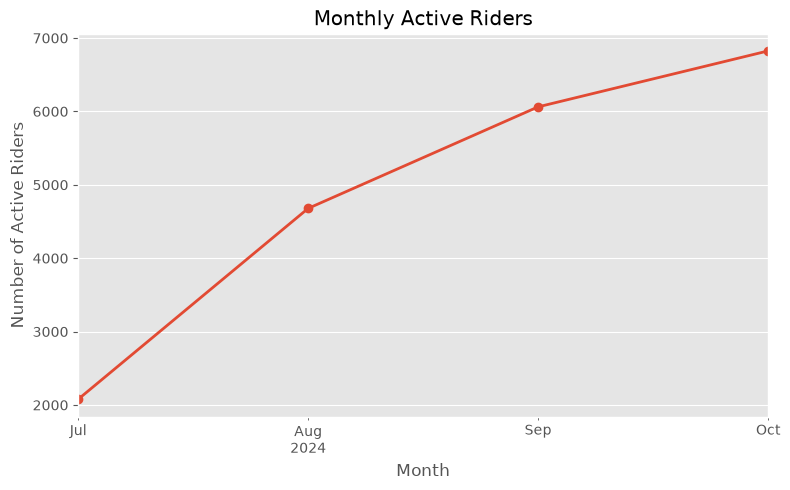

In [17]:
# Plot monthly trend of active riders
plt.figure(figsize=(8,5))

monthly_active.plot(
    marker="o",
    linewidth=2
)

plt.title("Monthly Active Riders")
plt.xlabel("Month")
plt.ylabel("Number of Active Riders")
plt.grid(True)

plt.tight_layout()

plt.savefig("monthly_active_riders.png")

plt.show()

### Observation

The number of active riders gradually increases from July to October, indicating a decline in rider retention over time.

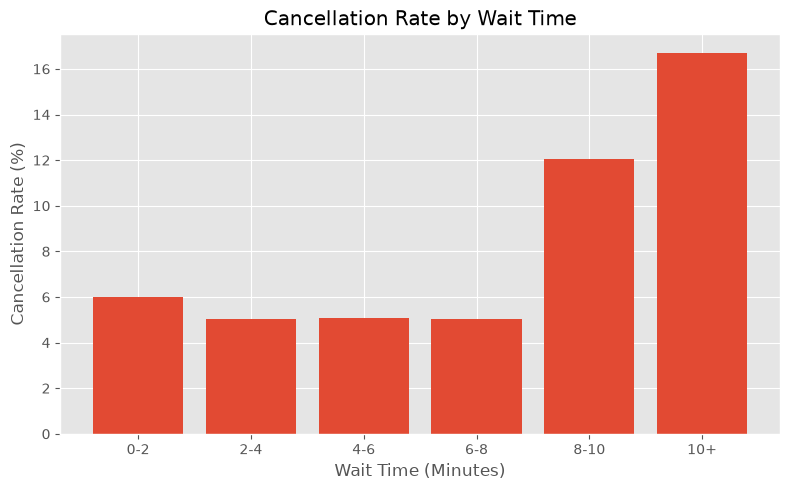

In [18]:
# Plot cancellation rate by wait time group
plt.figure(figsize=(8,5))

plt.bar(
    wait_cancel["wait_group"],
    wait_cancel["Cancellation Rate (%)"]
)

plt.title("Cancellation Rate by Wait Time")
plt.xlabel("Wait Time (Minutes)")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()

plt.savefig("cancellation_rate_by_wait.png")

plt.show()

### Observation

Cancellation rates increase as waiting time becomes longer.

Trips with waiting times above eight minutes have noticeably higher cancellation rates.

In [19]:
# Extract month from trip date for trend analysis
trip_df["month"] = trip_df["trip_date"].dt.to_period("M")

In [20]:
# Calculate the average rating for each rider segment by month
rating_trend = (
    trip_df
    .groupby(["month","rider_segment"])["rating"]
    .mean()
    .unstack()
)

rating_trend

rider_segment,Budget,Premium,Regular
month,,,
2024-07,4.067426,4.098870,4.100770
2024-08,4.078261,4.080493,4.099682
2024-09,3.590847,3.566677,3.566888
2024-10,3.429489,3.435228,3.420288


<Figure size 800x500 with 0 Axes>

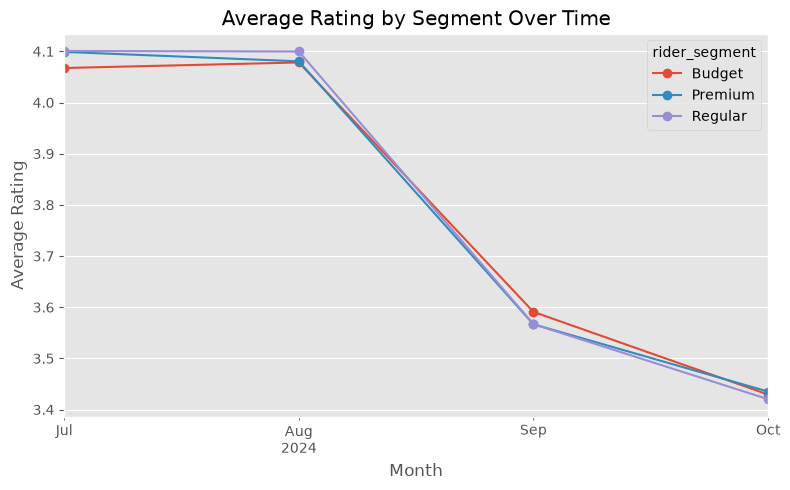

In [21]:
# Plot average rating trend by rider segment
plt.figure(figsize=(8,5))

rating_trend.plot(
    marker="o",
    figsize=(8,5)
)

plt.title("Average Rating by Segment Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")

plt.grid(True)

plt.tight_layout()

plt.savefig("average_rating_segment.png")

plt.show()

### Observation

Average ratings remain relatively stable across the four months.

The differences between rider segments are small, indicating similar customer satisfaction levels.

## Table 1: Total Active Riders by Month

In [22]:
# Active Riders by Month

trip_df["trip_date"] = pd.to_datetime(trip_df["trip_date"])
trip_df["month"] = trip_df["trip_date"].dt.to_period("M").astype(str)

active_riders = (
    trip_df[trip_df["trip_status"] == "Completed"]
    .groupby("month")["rider_id"]
    .nunique()
    .reset_index(name="Active Riders")
)

active_riders

,month,Active Riders
0,2024-07,2079
1,2024-08,4679
2,2024-09,6062
3,2024-10,6824


In [23]:
active_riders.to_csv("active_riders_by_month.csv", index=False)

## Table 2: Cancellation Rate by Month

In [24]:
monthly_cancel = (
    trip_df.groupby("month")["trip_status"]
    .apply(lambda x: (x=="Cancelled").mean()*100)
    .reset_index(name="Cancellation Rate (%)")
)

monthly_cancel

,month,Cancellation Rate (%)
0,2024-07,4.567640
1,2024-08,5.117475
2,2024-09,12.076158
3,2024-10,14.096916


In [25]:
monthly_cancel.to_csv("monthly_cancellation_rate.csv",index=False)

## Table 3: Average Wait Time by Month

In [26]:
monthly_wait = (
    trip_df.groupby("month")["wait_time_min"]
    .mean()
    .reset_index(name="Average Wait Time")
)

monthly_wait

,month,Average Wait Time
0,2024-07,4.504457
1,2024-08,4.505566
2,2024-09,9.580101
3,2024-10,11.022042


In [27]:
monthly_wait.to_csv("monthly_wait_time.csv",index=False)

## Table 4: Segment Performance

In [28]:
segment_summary.to_csv("segment_performance.csv")